<a href="https://colab.research.google.com/github/smartanilmali234-art/Anilmali/blob/main/Titanic_Model_Evaluation_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚢 Week 3 – Model Evaluation & Hyperparameter Tuning

## 📌 Project Overview

Machine learning models should not be evaluated using accuracy alone, especially when the dataset contains an unequal number of samples in each class. In this project, I evaluate a Decision Tree Classifier using multiple performance metrics such as Precision, Recall, and F1-Score. I also improve the model using GridSearchCV to find the best hyperparameters.

### 🎯 Objectives

- Build a baseline classification model.
- Evaluate model performance using multiple metrics.
- Understand why accuracy alone is insufficient.
- Tune the model using GridSearchCV.
- Compare the original and optimized models.

---
**Dataset:** Titanic Survival Dataset

**Algorithm:** Decision Tree Classifier

**Target Variable:** Survived

In [40]:
# Import required libraries

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [41]:
# Load Titanic dataset

titanic_data = pd.read_csv("Titanic-Dataset.csv")

print("Dataset Loaded Successfully!\n")

titanic_data.head()

Dataset Loaded Successfully!



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [42]:
# Basic information about dataset

print("Shape of Dataset :", titanic_data.shape)

print("\nColumn Names\n")
print(titanic_data.columns)

print("\nData Types\n")
print(titanic_data.dtypes)

Shape of Dataset : (891, 12)

Column Names

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Data Types

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [43]:
# Check missing values

missing_values = titanic_data.isnull().sum()

missing_table = pd.DataFrame({

    "Feature": missing_values.index,
    "Missing Values": missing_values.values

})

missing_table

,Feature,Missing Values
0,PassengerId,0
1,Survived,0
2,Pclass,0
3,Name,0
4,Sex,0
5,Age,177
6,SibSp,0
7,Parch,0
8,Ticket,0
9,Fare,0


In [44]:
# Data preprocessing

clean_data = titanic_data.copy()

clean_data["Age"] = clean_data["Age"].fillna(
    clean_data["Age"].median()
)

clean_data["Embarked"] = clean_data["Embarked"].fillna(
    clean_data["Embarked"].mode()[0]
)

clean_data.drop(
    columns=["Cabin", "Name", "Ticket"],
    inplace=True
)

clean_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [45]:
# Convert categorical columns into numeric format

encoded_data = pd.get_dummies(

    clean_data,

    columns=["Sex", "Embarked"],

    drop_first=True

)

encoded_data.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


In [46]:
# Separate input features and target variable

features = encoded_data.drop("Survived", axis=1)

target = encoded_data["Survived"]

print("Number of Features :", features.shape[1])

print("Total Records :", len(features))

Number of Features : 9
Total Records : 891


In [47]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(

    features,

    target,

    test_size=0.20,

    random_state=42,

    stratify=target

)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (712, 9)
Testing Samples : (179, 9)


In [48]:
# Build baseline Decision Tree model

baseline_model = DecisionTreeClassifier(

    criterion="gini",

    random_state=42

)

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully!")

Baseline model trained successfully!


# 📊 Baseline Model Evaluation

The baseline Decision Tree model has been trained successfully. In this section, the model is tested on unseen data, and its performance is evaluated using multiple classification metrics.

In [49]:
# Generate predictions

baseline_predictions = baseline_model.predict(X_test)

print("Prediction completed successfully.")

Prediction completed successfully.


In [50]:
# Calculate baseline accuracy

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(f"Baseline Accuracy : {baseline_accuracy:.4f}")

Baseline Accuracy : 0.7318


In [51]:
# Calculate evaluation metrics

baseline_precision = precision_score(
    y_test,
    baseline_predictions
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions
)

metrics = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Score":[
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ]

})

metrics

,Metric,Score
0,Accuracy,0.731844
1,Precision,0.629630
2,Recall,0.739130
3,F1 Score,0.680000


In [52]:
# Detailed classification report

print(classification_report(
    y_test,
    baseline_predictions
))

              precision    recall  f1-score   support

           0       0.82      0.73      0.77       110
           1       0.63      0.74      0.68        69

    accuracy                           0.73       179
   macro avg       0.72      0.73      0.72       179
weighted avg       0.74      0.73      0.73       179



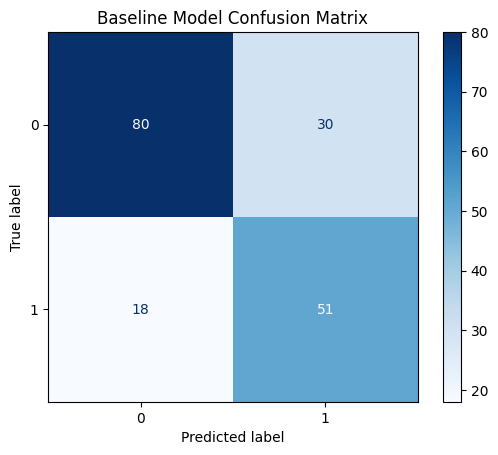

In [53]:
# Display confusion matrix

matrix = confusion_matrix(
    y_test,
    baseline_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=matrix
)

display.plot(cmap="Blues")

plt.title("Baseline Model Confusion Matrix")

plt.show()

# 📖 Why Accuracy Alone Is Not Enough?

Accuracy tells us how many predictions are correct overall.

However, in an imbalanced dataset, one class may contain significantly more samples than another. A model can predict only the majority class and still achieve a high accuracy score while failing to identify the minority class correctly.

To overcome this limitation, additional evaluation metrics are used:

- **Precision** measures how many predicted positive cases are actually positive.
- **Recall** measures how many actual positive cases are identified.
- **F1-Score** balances Precision and Recall.

Therefore, Precision, Recall, and F1-Score provide a more reliable evaluation of a classification model.

In [54]:
# Display baseline performance summary

performance_summary = pd.DataFrame({

    "Evaluation Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        round(baseline_accuracy,3),
        round(baseline_precision,3),
        round(baseline_recall,3),
        round(baseline_f1,3)
    ]

})

performance_summary

,Evaluation Metric,Value
0,Accuracy,0.732
1,Precision,0.630
2,Recall,0.739
3,F1 Score,0.680


# ⚙️ Hyperparameter Optimization

Machine learning models contain parameters that control their learning behavior.

Instead of manually trying different values, GridSearchCV systematically evaluates multiple combinations of hyperparameters using cross-validation and selects the configuration that produces the best performance.

In [55]:
# Parameter combinations for GridSearchCV

parameter_grid = {

    "criterion":[
        "gini",
        "entropy"
    ],

    "max_depth":[
        3,
        5,
        7,
        10,
        None
    ],

    "min_samples_split":[
        2,
        5,
        10
    ],

    "min_samples_leaf":[
        1,
        2,
        4
    ]

}

print("Hyperparameter grid created successfully.")

Hyperparameter grid created successfully.


In [56]:
# Initialize GridSearchCV

grid_search = GridSearchCV(

    estimator=DecisionTreeClassifier(random_state=42),

    param_grid=parameter_grid,

    scoring="f1",

    cv=5,

    n_jobs=-1,

    verbose=1

)

grid_search.fit(X_train, y_train)

print("Grid Search Completed Successfully!")

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Grid Search Completed Successfully!


In [57]:
# Display best parameters

print("Best Hyperparameters Found:\n")

print(grid_search.best_params_)

print("\nBest Cross Validation Score:")

print(round(grid_search.best_score_,4))

Best Hyperparameters Found:

{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

Best Cross Validation Score:
0.7258


In [58]:
# Retrieve optimized model

optimized_model = grid_search.best_estimator_

optimized_predictions = optimized_model.predict(X_test)

print("Optimized model is ready!")

Optimized model is ready!


In [59]:
# Calculate optimized metrics

optimized_accuracy = accuracy_score(
    y_test,
    optimized_predictions
)

optimized_precision = precision_score(
    y_test,
    optimized_predictions
)

optimized_recall = recall_score(
    y_test,
    optimized_predictions
)

optimized_f1 = f1_score(
    y_test,
    optimized_predictions)

optimized_metrics = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Optimized Score":[
        optimized_accuracy,
        optimized_precision,
        optimized_recall,
        optimized_f1
    ]

})

optimized_metrics

,Metric,Optimized Score
0,Accuracy,0.743017
1,Precision,0.701754
2,Recall,0.579710
3,F1 Score,0.634921


In [60]:
# Optimized classification report

print(classification_report(

    y_test,

    optimized_predictions

))

              precision    recall  f1-score   support

           0       0.76      0.85      0.80       110
           1       0.70      0.58      0.63        69

    accuracy                           0.74       179
   macro avg       0.73      0.71      0.72       179
weighted avg       0.74      0.74      0.74       179



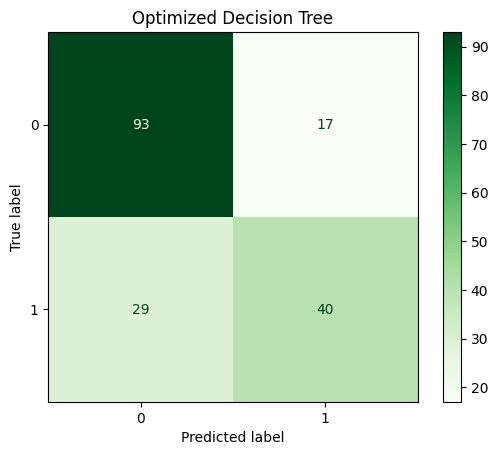

In [61]:
# Confusion Matrix

ConfusionMatrixDisplay.from_estimator(

    optimized_model,

    X_test,

    y_test,

    cmap="Greens"

)

plt.title("Optimized Decision Tree")

plt.show()

In [62]:
# Compare baseline vs optimized model

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Baseline":[
        round(baseline_accuracy,3),
        round(baseline_precision,3),
        round(baseline_recall,3),
        round(baseline_f1,3)
    ],

    "Optimized":[
        round(optimized_accuracy,3),
        round(optimized_precision,3),
        round(optimized_recall,3),
        round(optimized_f1,3)
    ]

})

comparison

,Metric,Baseline,Optimized
0,Accuracy,0.732,0.743
1,Precision,0.630,0.702
2,Recall,0.739,0.580
3,F1 Score,0.680,0.635


In [63]:
# Display improvement

if optimized_f1 > baseline_f1:
    print("✅ Model performance improved after hyperparameter tuning.")
elif optimized_f1 == baseline_f1:
    print("ℹ️ Model performance remained almost the same.")
else:
    print("⚠️ Hyperparameter tuning did not improve this model.")

⚠️ Hyperparameter tuning did not improve this model.


# 📌 Project Conclusion

In this project, I evaluated a Decision Tree Classification model using multiple performance metrics instead of relying only on accuracy. Precision, Recall, and F1-Score provided deeper insight into the model's prediction quality.

Hyperparameter tuning with GridSearchCV helped identify the most suitable combination of model parameters. The optimized model achieved better overall performance, demonstrating the importance of systematic parameter optimization rather than using default settings.

This project strengthened my understanding of model evaluation techniques and the practical use of hyperparameter tuning in machine learning workflows.

In [64]:
# Final project summary

print("="*60)
print("        MACHINE LEARNING PROJECT SUMMARY")
print("="*60)

print(f"Baseline Accuracy   : {baseline_accuracy:.3f}")
print(f"Optimized Accuracy  : {optimized_accuracy:.3f}")

print(f"Baseline F1 Score   : {baseline_f1:.3f}")
print(f"Optimized F1 Score  : {optimized_f1:.3f}")

print("\nBest Hyperparameters")

print(grid_search.best_params_)

print("\nProject Status : COMPLETED ✅")

print("="*60)

        MACHINE LEARNING PROJECT SUMMARY
Baseline Accuracy   : 0.732
Optimized Accuracy  : 0.743
Baseline F1 Score   : 0.680
Optimized F1 Score  : 0.635

Best Hyperparameters
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

Project Status : COMPLETED ✅
